# Lab — Exploratory Data Analysis with Ames Housing

## Guiding Question

> **What factors appear to influence home sale price?**

In this lab, you will use EDA to investigate patterns in the Ames Housing dataset.

Remember: EDA is not a checklist. It is a process of asking questions, exploring patterns, and explaining what the data suggests.


## Part 1 — Load and Inspect the Data

Load the dataset and inspect its basic structure.

**hint**: use `.head()`, `.shape`, etc.


In [2]:
# imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
RAW = Path("..\data") / "raw"
PROCESSED = Path("..\data") / "processed"

ames = pd.read_csv(RAW/"ames.csv")

In [3]:
# ames.head()
print(ames.shape)
ames.info() 

(2930, 75)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 75 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rownames            2930 non-null   int64  
 1   MS_SubClass         2930 non-null   object 
 2   MS_Zoning           2930 non-null   object 
 3   Lot_Frontage        2930 non-null   int64  
 4   Lot_Area            2930 non-null   int64  
 5   Street              2930 non-null   object 
 6   Alley               2930 non-null   object 
 7   Lot_Shape           2930 non-null   object 
 8   Land_Contour        2930 non-null   object 
 9   Utilities           2930 non-null   object 
 10  Lot_Config          2930 non-null   object 
 11  Land_Slope          2930 non-null   object 
 12  Neighborhood        2930 non-null   object 
 13  Condition_1         2930 non-null   object 
 14  Condition_2         2930 non-null   object 
 15  Bldg_Type           2930 non-null   object 


In [4]:
ames.head()

,rownames,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,...,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,1,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,...,No_Fence,NaN,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,2,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,...,Minimum_Privacy,NaN,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,...,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,4,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,...,No_Fence,NaN,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,5,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,...,Minimum_Privacy,NaN,0,3,2010,WD,Normal,189900,-93.638933,42.060899


### Reflection

- How many rows and columns are in the dataset?
##### 2930 rows, 75 columns
- Which column appears to represent the home sale price?
##### Sale_Price
- Which variables appear numeric
##### all the variables that have int64 or float64 are numeric
- Which variables appear categorical?
##### all the variables that are defined as objects have categories

## Part 2 — Focus the Dataset

The full dataset has many columns. For this lab, we will focus on a smaller set of variables.


In [5]:
columns_to_use = [
    'Sale_Price',
    'Gr_Liv_Area',
    'Overall_Cond',
    'Year_Built',
    'Lot_Area',
    'Lot_Frontage',
    'Neighborhood',
    'House_Style',
    'Garage_Type',
    'Central_Air'
]

housing = ames[columns_to_use].copy()
housing.head()

,Sale_Price,Gr_Liv_Area,Overall_Cond,Year_Built,Lot_Area,Lot_Frontage,Neighborhood,House_Style,Garage_Type,Central_Air
0,215000,1656,Average,1960,31770,141,North_Ames,One_Story,Attchd,Y
1,105000,896,Above_Average,1961,11622,80,North_Ames,One_Story,Attchd,Y
2,172000,1329,Above_Average,1958,14267,81,North_Ames,One_Story,Attchd,Y
3,244000,2110,Average,1968,11160,93,North_Ames,One_Story,Attchd,Y
4,189900,1629,Average,1997,13830,74,Gilbert,Two_Story,Attchd,Y


In [6]:
# call .info() on the new dataframe
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Sale_Price    2930 non-null   int64 
 1   Gr_Liv_Area   2930 non-null   int64 
 2   Overall_Cond  2930 non-null   object
 3   Year_Built    2930 non-null   int64 
 4   Lot_Area      2930 non-null   int64 
 5   Lot_Frontage  2930 non-null   int64 
 6   Neighborhood  2930 non-null   object
 7   House_Style   2930 non-null   object
 8   Garage_Type   2930 non-null   object
 9   Central_Air   2930 non-null   object
dtypes: int64(5), object(5)
memory usage: 229.0+ KB


### Reflection

- Why might it be useful to focus on fewer variables during EDA?
##### since we are doing this analysis by hand and aren't running a full model its better to start small
- Which selected variables are numeric?
##### sales price, living area, year built, lot area, lot frontage
- Which selected variables are categorical?
##### overall condition, neighborhood, house style, garage type, central air

## Part 3 — Missing Values

Before analyzing relationships, check for missing values.

Then fill in the missing values with an appropriate value.

**DO NOT HARDCODE THE VALUE TO FILL THE MISSING VALUE**

Use `.fillna()`

In [7]:
housing.isna().sum() 

Sale_Price      0
Gr_Liv_Area     0
Overall_Cond    0
Year_Built      0
Lot_Area        0
Lot_Frontage    0
Neighborhood    0
House_Style     0
Garage_Type     0
Central_Air     0
dtype: int64

In [8]:
numeric_cols = housing.select_dtypes(include='number').columns
categorical_cols = housing.select_dtypes(exclude='number').columns

print('Numeric columns:', list(numeric_cols))
print('Categorical columns:', list(categorical_cols))

Numeric columns: ['Sale_Price', 'Gr_Liv_Area', 'Year_Built', 'Lot_Area', 'Lot_Frontage']
Categorical columns: ['Overall_Cond', 'Neighborhood', 'House_Style', 'Garage_Type', 'Central_Air']


In [9]:
# Fill the numeric columns with a summary statistic
housing[numeric_cols] = housing[numeric_cols].fillna(housing[numeric_cols].median())

# Fill the categorical columns with "Missing"
housing[categorical_cols] = housing[categorical_cols].fillna("Missing")

### Reflection

- Which columns had missing values?
##### no missing values
- Why might the median be safer than the mean for numeric imputation?
##### median is safer as it ignores any outliers
- Why might we use `'Missing'` instead of dropping rows for categorical variables?
##### we don't want to delete good data if we can avoid it

## Part 4 — Summary Statistics for Numeric Variables

Explore individual numeric variables.

Manually caluclate the mean and median and then compare your calculation with Pandas.

In [10]:
def calc_mean_median(col):
    mean=sum(col)/len(col)
    sorted_col=sorted(col)
    n=len(sorted_col)
    if n%2==1:
        median=sorted_col[n//2]
    else:
        median=(sorted_col[n//2]+sorted_col[n//2])/2
    return mean, median 

In [11]:
for value in numeric_cols:
    mean, median = calc_mean_median(housing[value])
    print("manual",f"{value}: mean={mean:.2f}, median={median:.2f}")
    print("Python", value, "mean is ",housing[value].mean(), "median is ", housing[value].median())  

manual Sale_Price: mean=180796.06, median=160000.00
Python Sale_Price mean is  180796.0600682594 median is  160000.0
manual Gr_Liv_Area: mean=1499.69, median=1442.00
Python Gr_Liv_Area mean is  1499.6904436860068 median is  1442.0
manual Year_Built: mean=1971.36, median=1973.00
Python Year_Built mean is  1971.3563139931741 median is  1973.0
manual Lot_Area: mean=10147.92, median=9439.00
Python Lot_Area mean is  10147.921843003413 median is  9436.5
manual Lot_Frontage: mean=57.65, median=63.00
Python Lot_Frontage mean is  57.64778156996587 median is  63.0


In [12]:
# Manual calculation: population variance and standard deviation
# Note: Pandas uses sample standard deviation by default, so results may differ slightly.
def calc_var_std(col):
    squared_diffs=(col-col.mean())**2
    variance = squared_diffs.mean()
    std_dev = variance**0.5
    return variance, std_dev

In [13]:
for value in numeric_cols:
    var, std = calc_var_std(housing[value])
    print("manual",f"{value}: variance={var:.2f}, std={std:.2f}")
    print("Python", value, "variance is ",housing[value].var(), "std is ", housing[value].std())  

manual Sale_Price: variance=6379705498.41, std=79873.06
Python Sale_Price variance is  6381883615.688427 std is  79886.69235666493
manual Gr_Liv_Area: variance=255452.02, std=505.42
Python Gr_Liv_Area variance is  255539.2353132209 std is  505.5088874720413
manual Year_Built: variance=914.47, std=30.24
Python Year_Built variance is  914.7818396009353 std is  30.2453606293748
manual Lot_Area: variance=62073487.17, std=7878.67
Python Lot_Area variance is  62094679.88907532 std is  7880.017759439081
manual Lot_Frontage: variance=1121.83, std=33.49
Python Lot_Frontage variance is  1122.212533485909 std is  33.49944079362981


### Reflection

- Is the mean sale price higher or lower than the median?
##### mean sale price is higher
- What might that tell you about the distribution of sale prices?
##### there are more cheaper houses and and a few expensive houses
- Is there a wide spread in sale prices?
##### yes, the standard deviation is half the median price - wide spread

## Part 5 — Categorical Variables

For categorical variables, ask: **What categories exist, and how common is each category?**


In [14]:
for value in categorical_cols:
    print(housing[value].value_counts(normalize=True)*100)
    print()

Overall_Cond
Average          56.450512
Above_Average    18.191126
Good             13.310580
Very_Good         4.914676
Below_Average     3.447099
Fair              1.706485
Excellent         1.399317
Poor              0.341297
Very_Poor         0.238908
Name: proportion, dtype: float64

Neighborhood
North_Ames                                 15.119454
College_Creek                               9.112628
Old_Town                                    8.156997
Edwards                                     6.621160
Somerset                                    6.211604
Northridge_Heights                          5.665529
Gilbert                                     5.631399
Sawyer                                      5.153584
Northwest_Ames                              4.470990
Sawyer_West                                 4.266212
Mitchell                                    3.890785
Brookside                                   3.686007
Crawford                                    3.515358
Iowa_DOT

<Axes: xlabel='Neighborhood'>

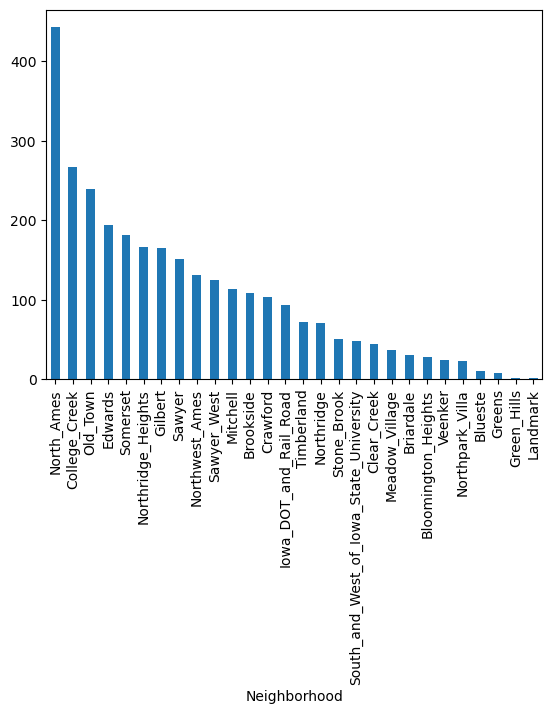

In [15]:
housing["Neighborhood"].value_counts().plot(kind="bar")

### Reflection

- Which neighborhood appears most often?
##### north ames is the most popular neighborhood
- Are some categories rare?
##### the most rare categories are Landmark and Green Hills neighborhoods
- Why are proportions sometimes more helpful than raw counts?
##### count can often be deceiving - i sould have missed Green Hills neighborhood until i saw the percentage


## Part 6 — Grouped Summary Statistics

Use `.groupby()` to compare sale prices across categories.


In [16]:
summary_by_neighborhood = housing.groupby("Neighborhood")["Sale_Price"].agg(["mean", "median"]).sort_values("mean", ascending=False)
print(summary_by_neighborhood)

                                                  mean    median
Neighborhood                                                    
Northridge                               330319.126761  302000.0
Stone_Brook                              324229.196078  319000.0
Northridge_Heights                       322018.265060  317750.0
Green_Hills                              280000.000000  280000.0
Veenker                                  248314.583333  250250.0
Timberland                               246599.541667  232106.5
Somerset                                 229707.324176  225500.0
Clear_Creek                              208662.090909  197500.0
Crawford                                 207550.834951  200624.0
College_Creek                            201803.434457  200000.0
Bloomington_Heights                      196661.678571  191500.0
Greens                                   193531.250000  198000.0
Gilbert                                  190646.575758  183000.0
Northwest_Ames           


Calculate average sale price by House_Style.
Calculate average sale price by Central_Air.
Sort your results from highest to lowest.


In [17]:
average_by_style = housing.groupby("House_Style")["Sale_Price"].mean().sort_values(ascending=False)
print(average_by_style)

House_Style
Two_and_Half_Fin    220000.000000
Two_Story           206990.159221
One_Story           178699.875084
Two_and_Half_Unf    177158.333333
SLvl                165527.382812
SFoyer              143472.662651
One_and_Half_Fin    137529.923567
One_and_Half_Unf    109663.157895
Name: Sale_Price, dtype: float64


In [18]:
average_by_air = housing.groupby("Central_Air")["Sale_Price"].mean().sort_values(ascending=False)
print(average_by_air)

Central_Air
Y    186452.787857
N    101890.479592
Name: Sale_Price, dtype: float64


### Reflection

- Which neighborhoods have the highest average sale price?
##### Northridge, Stone Brook and Northridge Heights have the highest average
- Do mean and median tell the same story?
##### generaly, yes, but NOrthridge Heights has the highest median
- Does central air appear related to sale price?
###### central air is VERY important


## Part 7 — Covariance and Correlation

Use covariance and correlation to investigate relationships between numeric variables.


Create a correlation matrix for the numeric variables.
Identify which numeric variables have the strongest correlation with Sale_Price.
Calculate the covariance between Gr_Liv_Area and Sale_Price.
Calculate the correlation between Gr_Liv_Area and Sale_Price.

In [19]:
housing[numeric_cols].corr()

,Sale_Price,Gr_Liv_Area,Year_Built,Lot_Area,Lot_Frontage
Sale_Price,1.000000,0.706780,0.558426,0.266549,0.201875
Gr_Liv_Area,0.706780,1.000000,0.241726,0.285599,0.186767
Year_Built,0.558426,0.241726,1.000000,0.023258,0.026130
Lot_Area,0.266549,0.285599,0.023258,1.000000,0.136862
Lot_Frontage,0.201875,0.186767,0.026130,0.136862,1.000000


Gr Liv Area has the strongest correlation with Sale Price, socond is Year Built

In [20]:
housing[['Gr_Liv_Area', 'Sale_Price']].cov()

,Gr_Liv_Area,Sale_Price
Gr_Liv_Area,2.555392e+05,2.854220e+07
Sale_Price,2.854220e+07,6.381884e+09


In [21]:
housing[['Gr_Liv_Area', 'Sale_Price']].corr()

,Gr_Liv_Area,Sale_Price
Gr_Liv_Area,1.00000,0.70678
Sale_Price,0.70678,1.00000


In [22]:
ames.select_dtypes(include='number').corr()[['Sale_Price']].sort_values(by='Sale_Price', ascending=False)

,Sale_Price
Sale_Price,1.000000
Gr_Liv_Area,0.706780
Garage_Cars,0.647562
Garage_Area,0.640138
Total_Bsmt_SF,0.632529
First_Flr_SF,0.621676
Year_Built,0.558426
Full_Bath,0.545604
Year_Remod_Add,0.532974
Mas_Vnr_Area,0.502196


### Reflection

- Which numeric variable appears most related to sale price?
##### the living area is most related to sale price, but i see the size of the garage is also related.
- Is the relationship positive or negative?
##### the relationship is positive
- Why is correlation easier to interpret than covariance?
##### correlation is normalized between -1 and 1, so its easier to interpret
- What does correlation not prove?
##### causation

## Part 8 — Pandas Plots

Use Pandas plotting methods to support your analysis.


Text(0, 0.5, 'Frequency')

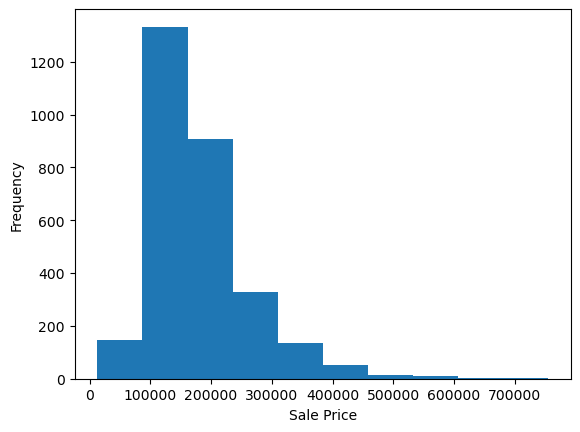

In [26]:
import matplotlib.pyplot as plt
housing['Sale_Price'].plot.hist()
plt.xlabel('Sale Price')
plt.ylabel('Frequency')

Text(0, 0.5, 'Sale Price')

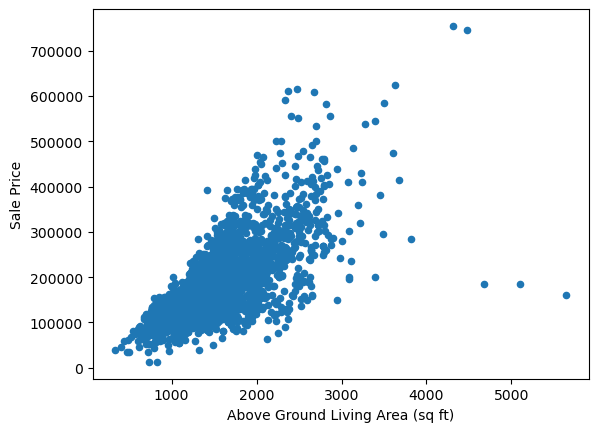

In [27]:
housing.plot.scatter(x='Gr_Liv_Area', y='Sale_Price')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price')

Text(0, 0.5, 'Average Sale Price')

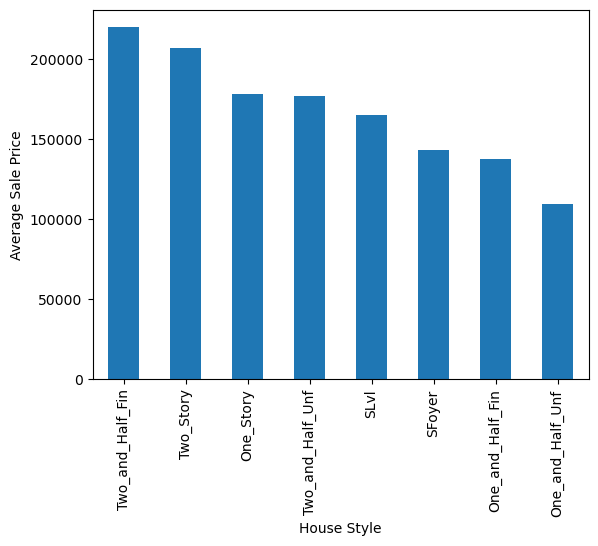

In [28]:
average_by_style.plot.bar()
plt.xlabel('House Style')
plt.ylabel('Average Sale Price')

Text(0, 0.5, 'Average Sale Price')

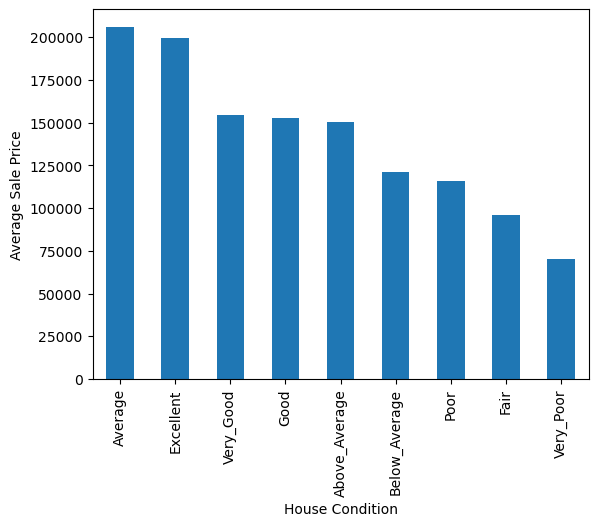

In [29]:
average_by_condition = housing.groupby("Overall_Cond")["Sale_Price"].mean().sort_values(ascending=False)
average_by_condition.plot.bar()
plt.xlabel('House Condition')
plt.ylabel('Average Sale Price')

### Reflection

- What does the sale price distribution look like?
##### it is right - skewed
- Does living area appear related to sale price?
##### yes
- Which categorical comparison was most useful?
##### House style was most useful - there was more of a spread in the plots


## Part 9 — Final Written Analysis

Write a short summary of your findings.

Your response should answer:

1. What factors appear most related to sale price?
the amount of living space and size of the garage
3. What evidence supports your answer?
they both have strong correlation (.71 and .65 to sale price)
5. What surprised you?
the average house condition was the most expensive
6. What would you investigate next?
maybe the average house condition is skewed and a few VERY expensive houses influenced the answer, maybe we just had a BUNCH of average houses - did we really have a large enough sample of the other houses?
8. What limitations should we keep in mind?
things like condition of the house are subjective

In [ ]:
# Write your final analysis in a markdown cell below this one.

The analysis shows that the factors most strongly related to sale price are the amount of living space and the size of the garage. Both variables have strong positive correlations with sale price (about 0.71 for living area and 0.65 for garage size), indicating that larger homes and those with bigger garages tend to sell for higher prices. This is also supported by scatter plots, which show clear upward trends as these variables increase. One surprising finding was that homes with average overall condition had the highest average sale price, which is unexpected since higher-condition homes would typically be assumed to sell for more.

A useful next step would be to investigate whether this result is influenced by skewness or outliers, such as a few very expensive homes raising the average in the “average” condition category. It would also help to check whether there are enough homes in each condition group to make reliable comparisons. Finally, there are some limitations to keep in mind: variables like overall condition are subjective and may not be measured consistently, and correlation does not imply causation, meaning other factors not included in the analysis could also affect sale price.